In [39]:
import warnings
warnings.filterwarnings("ignore")

In [40]:
import pandas as pd

In [60]:
pd.read_csv(r"C:\Users\HP\Downloads\CreditRisk59.csv")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,LP002971,Male,Yes,4.0,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,Y
977,LP002975,Male,Yes,0.0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,Y
978,LP002980,Male,No,0.0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,Y
979,LP002986,Male,Yes,0.0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,N


In [61]:
cr=pd.read_csv(r"C:\Users\HP\Downloads\CreditRisk59.csv")

In [62]:
cr.isnull().sum()[cr.isnull().sum()>0]

Gender              24
Married              3
Dependents          25
Self_Employed       55
LoanAmount          27
Loan_Amount_Term    20
Credit_History      79
dtype: int64

In [63]:
cr.Gender.fillna('Male', inplace = True)
cr. Married. fillna('Yes', inplace = True)
cr. Dependents. fillna(0, inplace = True)
cr. LoanAmount.fillna(cr.LoanAmount.mean(), inplace = True)
cr. Loan_Amount_Term.fillna(cr.Loan_Amount_Term.mean(), inplace = True)
cr. Credit_History. fillna(0, inplace = True)
cr.Self_Employed.fillna('No', inplace= True)

In [64]:
cr.select_dtypes(include='object').columns

Index(['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [65]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [66]:
cr[cr.select_dtypes(include='object').columns] = cr[cr.select_dtypes(include='object').columns].apply(le.fit_transform)

In [67]:
cr1=cr # just for back up
cr=cr.drop(['Loan_ID'],axis=1)

In [68]:
cr

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849,0.0,142.51153,360.0,1.0,2,1
1,1,1,1.0,0,0,4583,1508.0,128.00000,360.0,1.0,0,0
2,1,1,0.0,0,1,3000,0.0,66.00000,360.0,1.0,2,1
3,1,1,0.0,1,0,2583,2358.0,120.00000,360.0,1.0,2,1
4,1,0,0.0,0,0,6000,0.0,141.00000,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
976,1,1,4.0,1,1,4009,1777.0,113.00000,360.0,1.0,2,1
977,1,1,0.0,0,0,4158,709.0,115.00000,360.0,1.0,2,1
978,1,0,0.0,0,0,3250,1993.0,126.00000,360.0,0.0,1,1
979,1,1,0.0,0,0,5000,2393.0,158.00000,360.0,1.0,0,0


In [69]:
from sklearn.model_selection import train_test_split
cr_train,cr_test=train_test_split(cr,test_size=.2)

In [70]:
cr.Loan_Status.value_counts()

Loan_Status
1    712
0    269
Name: count, dtype: int64

In [71]:
# over sampling
df1=cr_train[cr_train.Loan_Status==0]
cr_train=pd.concat([cr_train,df1,df1,df1,df1])
cr_train.shape

(1680, 12)

In [72]:
cr_train_x=cr_train.iloc[:,0:-1]
cr_train_y=cr_train.iloc[:,-1]

cr_test_x=cr_test.iloc[:,0:-1]
cr_test_y=cr_test.iloc[:,-1]

In [73]:
cr_test_y

696    0
299    0
156    1
35     1
315    1
      ..
526    1
573    0
436    1
817    1
456    1
Name: Loan_Status, Length: 197, dtype: int64

In [74]:
cr_test_x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
696,1,1,2.0,1,0,4136,0.0,149.00000,480.0,0.0,0
299,1,1,1.0,0,0,2014,2925.0,113.00000,360.0,1.0,2
156,1,1,1.0,0,0,6000,0.0,160.00000,360.0,0.0,0
35,1,1,0.0,0,0,2275,2067.0,142.51153,360.0,1.0,2
315,1,1,1.0,1,0,3399,1640.0,111.00000,180.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
526,1,1,0.0,0,0,3775,0.0,110.00000,360.0,1.0,1
573,1,1,2.0,1,0,6125,1625.0,187.00000,480.0,1.0,1
436,1,0,0.0,0,0,1926,1851.0,50.00000,360.0,1.0,1
817,0,1,0.0,0,0,3159,2374.0,108.00000,360.0,1.0,1


In [75]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

In [76]:
dt.fit(cr_train_x,cr_train_y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:
pred_train=dt.predict(cr_train_x)
pred_test=dt.predict(cr_test_x)

In [78]:
from sklearn.metrics import confusion_matrix
mat_test=confusion_matrix(cr_test_y,pred_test)
mat_test

array([[ 19,  26],
       [ 27, 125]])

In [79]:
125/(125+27)*100

82.23684210526315

In [80]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score

In [81]:
accuracy_score(cr_test_y,pred_test)

0.7309644670050761

In [82]:
recall_score(cr_test_y,pred_test)

0.8223684210526315

In [83]:
precision_score(cr_test_y,pred_test)

0.8278145695364238

In [84]:
f1_score(cr_test_y,pred_test)

0.8250825082508251

In [85]:
#fpr
26/(26+19)*100

57.77777777777777

In [86]:
pred_prob_test=dt.predict_proba(cr_test_x)
len(pred_prob_test)

197

In [87]:
from sklearn.metrics import roc_auc_score,roc_curve

In [88]:
roc_auc_score(cr_test_y,pred_prob_test[:,1])

0.6222953216374268

In [89]:
fpr,tpr,thre=roc_curve(cr_test_y,pred_prob_test[:,1])

In [90]:
import matplotlib.pyplot as plt

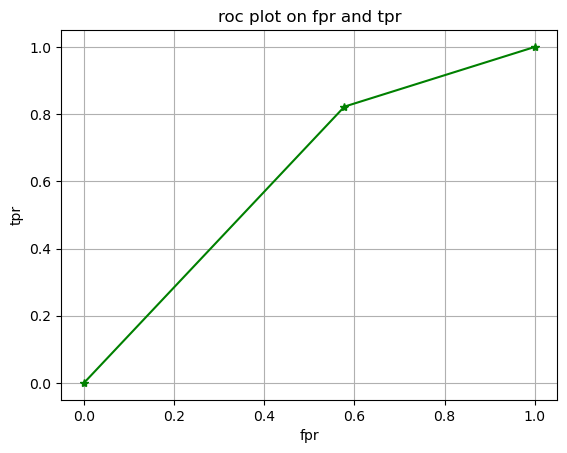

In [91]:
plt.plot(fpr,tpr,marker='*' , color='green')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('roc plot on fpr and tpr')
plt.grid()

# Grid Search

In [93]:
from sklearn.model_selection import GridSearchCV

In [94]:
search_dict = {'criterion':['gini','entropy'],
              'max_depth':range(4,9),
              'min_samples_split':[50,75,100]}

In [95]:
dt_ctg=DecisionTreeClassifier()
grid=GridSearchCV(dt_ctg,param_grid=search_dict)

In [97]:
grid.fit(cr_train_x,cr_train_y)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': range(4, 9), 'min_samples_split': [50, 75, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [98]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 50}

# Random Search

In [99]:
from sklearn.model_selection import RandomizedSearchCV

In [100]:
search_dict1 = {'criterion':['gini','entropy'],
              'max_depth':range(4,9),
              'min_samples_split':[50,75,100]}

In [102]:
dt_cr=DecisionTreeClassifier()

In [103]:
dt_cr=DecisionTreeClassifier()

In [104]:
random_search=RandomizedSearchCV(
        estimator=dt_ctg,
        param_distributions=search_dict1,
        n_iter=10,
        random_state=42,
        cv=5
)

In [105]:
random_search.fit(cr_train_x,cr_train_y)

,estimator,DecisionTreeClassifier()
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': range(4, 9), 'min_samples_split': [50, 75, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [106]:
random_search.best_params_

{'min_samples_split': 50, 'max_depth': 8, 'criterion': 'gini'}